In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from PIL import Image
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch 
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
test_img = Image.open('./Data/Angry/0.png')
print(test_img.mode)
print(test_img.size)


dataset_dir = './Data'

basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

full_dataset = ImageFolder(root=dataset_dir, transform=basic_transform)

L
(48, 48)


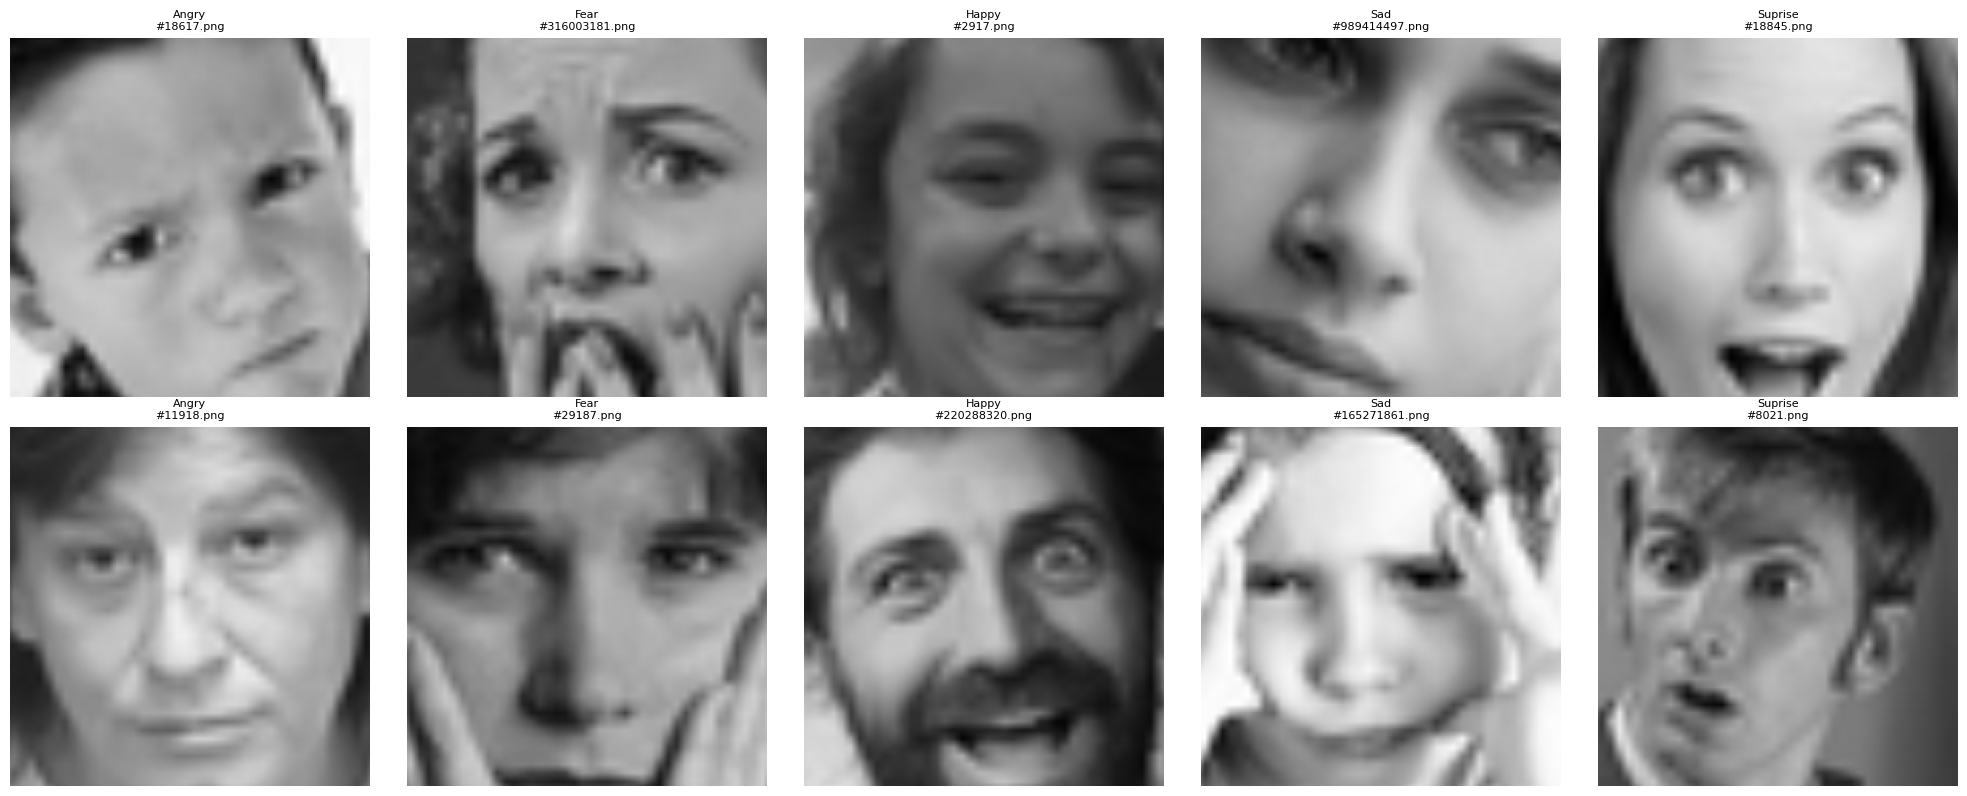

In [30]:
def show_examples(n_per_class = 2, figsize = (20,8)):
    import random
    random.seed(42)

    num_classes = len(full_dataset.classes)

    class_to_paths = {i: [] for i in range(num_classes)}
    for path, label in full_dataset.samples:
        class_to_paths[label].append(path)

    
    selected = {}
    for cls, paths in class_to_paths.items():
        if len(paths) == 0:
            selected[cls] = []
        else:
            selected[cls] = random.sample(paths, n_per_class)


    fig, axes = plt.subplots(n_per_class, num_classes, figsize=figsize)
    if n_per_class == 1:
        axes = np.expand_dims(axes , 0)

    disp_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224)
    ])

    for c in range(num_classes):
        for i in range(n_per_class):
            axes[i, c].axis('off')
            paths = selected.get(c, [])
            if i < len(paths):
                p = paths[i]
                try:
                    img = Image.open(p).convert('RGB')
                    img = disp_transform(img)
                    img_np = np.array(img) / 255
                    axes[i, c].imshow(img_np)
                    axes[i, c].set_title(f"{full_dataset.classes[c]}\n#{os.path.basename(p)}", fontsize=8)
                except Exception as e:
                    axes[i, c].text(0.5, 0.5, 'Error loading', ha='center')
            else:
                axes[i, c].text(0.5, 0.5, 'No image', ha='center')

    plt.tight_layout()
    plt.show()

show_examples()
            


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 10 * 10, 4068),
            nn.ReLU(),
            nn.Linear(4068, 7)
        )

        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        
        return x

    


In [ ]:
targets = np.array(s[1] for s in full_dataset.samples)
indicies = np.arange(len(full_dataset))

train_idx, temp_idx = train_test_split